# Тест SAM 3: сегментация мешков на реальном видео с конвейера

Цель: проверить, насколько хорошо SAM 3 (Promptable Concept Segmentation) находит мешки
на `input.mp4` по текстовому промпту — чтобы понять, годится ли модель для bootstrap-разметки
датасета под дообучение RTMDet (MMDetection).

**Про окружение:**
- `facebook/sam3` — gated-модель на HuggingFace: нужен одобренный доступ + `HF_TOKEN` в переменной окружения (или интерактивный логин).
- По документации Meta официально требуется CUDA GPU (848M параметров, CPU explicitly не поддерживается).
- Ноутбук написан для запуска в GPU-окружении (Colab / удалённая машина с CUDA). Ячейки сэмплирования кадров и визуализации GPU не требуют и проверяются локально.

Что делает ноутбук:
1. Берёт N кадров, равномерно распределённых по `input.mp4`.
2. Прогоняет каждый кадр через SAM 3 с текстовым промптом (например `"sack"`).
3. Визуализирует найденные маски/боксы/score поверх кадра.
4. Сохраняет результаты в COCO-подобном JSON — черновик для датасета под RTMDet.

In [1]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent  # bag_counting/
VIDEO_PATH = PROJECT_ROOT / "storage" / "input" / "input.mp4"
OUTPUT_DIR = NOTEBOOK_DIR.parent / "outputs" / "sam3_test"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_PROMPTS = ["sack", "bag on conveyor belt"]
N_SAMPLE_FRAMES = 12
SCORE_THRESHOLD = 0.5

assert VIDEO_PATH.exists(), f"video not found: {VIDEO_PATH}"
VIDEO_PATH

PosixPath('/home/batoshka/bag_counting/storage/input/input.mp4')

## 1. Сэмплирование кадров из видео

Эта часть не требует GPU/SAM3 и может быть проверена в любом окружении.

In [2]:
import cv2
import numpy as np


def sample_frames(video_path: Path, n: int) -> list[tuple[int, float, np.ndarray]]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(0, total_frames - 1, n, dtype=int)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame_bgr = cap.read()
        if not ok:
            continue
        frames.append((int(idx), float(idx) / fps, frame_bgr))

    cap.release()
    return frames


sampled_frames = sample_frames(VIDEO_PATH, N_SAMPLE_FRAMES)
print(f"sampled {len(sampled_frames)} frames")

sampled 12 frames


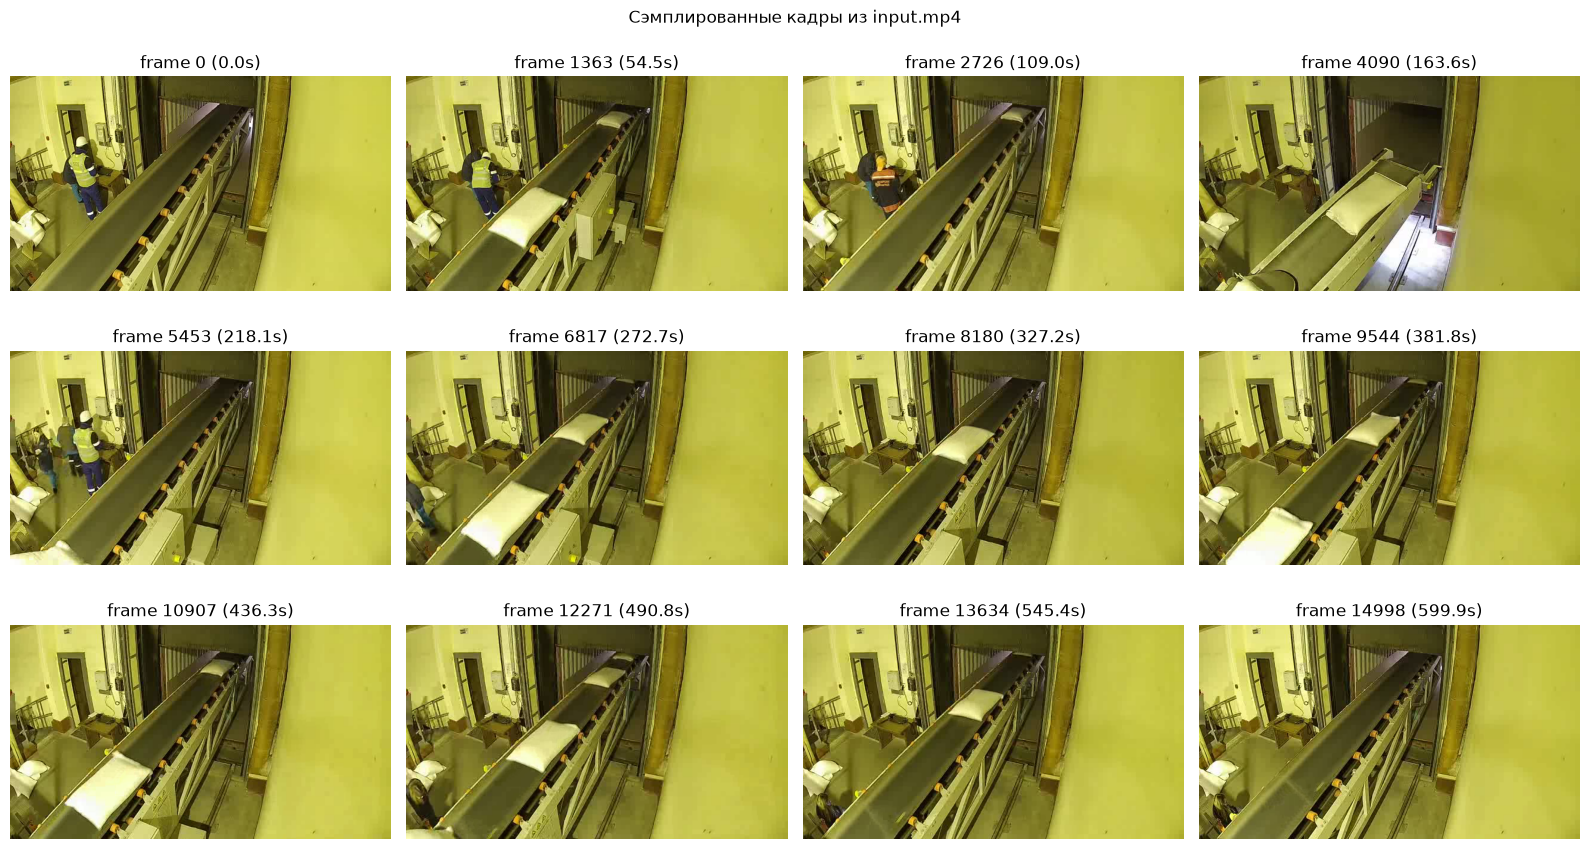

In [3]:
import matplotlib.pyplot as plt


def show_frames_grid(frames, cols: int = 4, title: str | None = None) -> None:
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (idx, ts, frame_bgr) in zip(axes, frames):
        ax.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {idx} ({ts:.1f}s)")
        ax.axis("off")
    for ax in axes[len(frames):]:
        ax.axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


show_frames_grid(sampled_frames, title="Сэмплированные кадры из input.mp4")

## 2. Авторизация в HuggingFace

Нужен одобренный доступ к `facebook/sam3`. Если есть `HF_TOKEN` в окружении — используем его,
иначе `login()` запросит токен интерактивно (сработает только если доступ уже одобрен).

In [4]:
import os

from huggingface_hub import login

hf_token = '***REMOVED-SECRET***'
if hf_token:
    login(token=hf_token)
    print("logged in via HF_TOKEN")
else:
    login()

logged in via HF_TOKEN


## 3. Загрузка SAM 3

Требует CUDA GPU по документации Meta. На CPU может не заработать или быть непрактично медленной —
ноутбук не блокирует запуск на CPU, но предупреждает.

In [3]:
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
model = build_sam3_image_model(
    bpe_path="sam3/assets/bpe_simple_vocab_16e6.txt.gz",
    device="cpu",
    eval_mode=True,
    checkpoint_path="sam3.safetensors",
    load_from_HF=False,
)
processor = Sam3Processor(model, device="cpu")
state = processor.set_image("your_image.jpg")
state = processor.set_text_prompt("white bicycle", state)
print(state["masks"].shape)

/home/batoshka/bag_counting/experiments/.venv/lib/python3.11/site-packages/sam3/model/sam3_video_inference.py:800: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)
/home/batoshka/bag_counting/experiments/.venv/lib/python3.11/site-packages/sam3/model/sam3_video_inference.py:908: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)
/home/batoshka/bag_counting/experiments/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [2]:
!uv pip install pycocotools

Using Python 3.11.14 environment at: /home/batoshka/bag_counting/experiments/.venv
Resolved 2 packages in 593ms                                         
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/481.61 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/481.61 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/481.61 KiB        
⠙ Preparing packages... (0/1)------------------- 41.41 KiB/481.61 KiB        
⠙ Preparing packages... (0/1)------------------- 57.41 KiB/481.61 KiB        
⠹ Preparing packages... (0/1)------------------- 61.91 KiB/481.61 KiB        
⠹ Preparing packages... (0/1)------------------- 61.91 KiB/481.61 KiB        
⠹ Preparing packages... (0/1)------------------- 77.91 KiB/481.61 KiB        
⠹ Preparing packages... (0/1)------------------- 93.91 KiB/481.61 KiB        
⠹ Preparing packages... (0/1)------------------- 109.91 KiB/481.

In [ ]:
import torch
from transformers import Sam3Model, Sam3Processor

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print(
        "WARNING: CUDA недоступна. По документации SAM3 GPU обязателен — "
        "инференс на CPU может упасть с ошибкой или быть непрактично медленным."
    )

MODEL_ID = "facebook/sam3"
model = Sam3Model.from_pretrained(MODEL_ID, device_map="auto" if device == "cuda" else None)
processor = Sam3Processor.from_pretrained(MODEL_ID)
if device == "cpu":
    model = model.to(device)
model.eval()
print(f"SAM3 loaded on {device}")

In [1]:
!uv pip install git+https://github.com/facebookresearch/sam3.git

Using Python 3.11.14 environment at: /home/batoshka/bag_counting/experiments/.venv
Resolved 52 packages in 1.70s                                        
Audited 52 packages in 3ms


## 4. Запуск text-prompt сегментации на сэмплированных кадрах

In [ ]:
from PIL import Image


def run_sam3_on_frame(frame_bgr: np.ndarray, text_prompt: str, threshold: float = SCORE_THRESHOLD) -> dict:
    image = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    result = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=threshold,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]
    return {
        "masks": result["masks"],    # [N, H, W] bool
        "boxes": result["boxes"],    # [N, 4] xyxy, абсолютные пиксели
        "scores": result["scores"],  # [N]
    }

In [ ]:
results_by_frame = []

for idx, ts, frame_bgr in sampled_frames:
    per_prompt = {}
    for prompt in TEXT_PROMPTS:
        per_prompt[prompt] = run_sam3_on_frame(frame_bgr, prompt)
        n_found = len(per_prompt[prompt]["scores"])
        print(f"frame {idx} ({ts:.1f}s) | prompt='{prompt}' -> {n_found} objects")
    results_by_frame.append(
        {"frame_idx": idx, "timestamp": ts, "frame_bgr": frame_bgr, "results": per_prompt}
    )

## 5. Визуализация масок и боксов

In [ ]:
def draw_overlay(frame_bgr: np.ndarray, boxes, scores, masks=None) -> np.ndarray:
    vis = frame_bgr.copy()

    if masks is not None and len(masks) > 0:
        overlay = vis.copy()
        for mask in masks:
            mask_np = mask.detach().cpu().numpy() if torch.is_tensor(mask) else np.asarray(mask)
            overlay[mask_np.astype(bool)] = (0, 200, 0)
        vis = cv2.addWeighted(overlay, 0.4, vis, 0.6, 0)

    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = (int(v) for v in box)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(
            vis, f"{float(score):.2f}", (x1, max(y1 - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1,
        )
    return vis


for entry in results_by_frame:
    for prompt, res in entry["results"].items():
        vis = draw_overlay(entry["frame_bgr"], res["boxes"], res["scores"], res["masks"])
        out_path = OUTPUT_DIR / f"frame{entry['frame_idx']:05d}_{prompt.replace(' ', '_')}.jpg"
        cv2.imwrite(str(out_path), vis)

        plt.figure(figsize=(8, 5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(
            f"frame {entry['frame_idx']} ({entry['timestamp']:.1f}s) | "
            f"'{prompt}' | {len(res['scores'])} found"
        )
        plt.axis("off")
        plt.show()

## 6. Экспорт черновика разметки (COCO-подобный формат)

Черновик для последующего дообучения RTMDet — перед использованием требует выборочной
проверки глазами (см. обсуждение про слипшиеся мешки/ложные срабатывания).

In [ ]:
import json


def export_coco_draft(results_by_frame: list[dict], prompt: str, out_path: Path) -> None:
    images, annotations = [], []
    ann_id = 1
    for img_id, entry in enumerate(results_by_frame, start=1):
        h, w = entry["frame_bgr"].shape[:2]
        images.append(
            {"id": img_id, "file_name": f"frame{entry['frame_idx']:05d}.jpg", "width": w, "height": h}
        )
        res = entry["results"][prompt]
        for box, score in zip(res["boxes"], res["scores"]):
            x1, y1, x2, y2 = (float(v) for v in box)
            annotations.append(
                {
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "area": (x2 - x1) * (y2 - y1),
                    "score": float(score),
                    "iscrowd": 0,
                }
            )
            ann_id += 1

    coco = {"images": images, "annotations": annotations, "categories": [{"id": 1, "name": "bag"}]}
    out_path.write_text(json.dumps(coco, indent=2))
    print(f"saved draft annotations ({len(annotations)} boxes) -> {out_path}")


export_coco_draft(results_by_frame, prompt=TEXT_PROMPTS[0], out_path=OUTPUT_DIR / "draft_annotations.json")

## Выводы

_Заполнить после прогона на GPU:_

- Какой промпт (`"sack"` vs `"bag on conveyor belt"` vs другие) даёт лучший recall/precision?
- Есть ли слипшиеся мешки, которые SAM3 сегментирует одним пятном вместо нескольких инстансов?
- Ложные срабатывания (тени, складки ленты, рабочий в кадре)?
- Нужна ли ручная докорректировка перед обучением RTMDet, и на скольких кадрах?